C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5964\3672400240.py:87: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(method='linear', inplace=True, limit_direction='both')


Class distribution: {0: 44792, 1: 3217}
Sequence shape: (47986, 12, 5)
Train samples: 38388
Test samples : 9598


C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 12, 128)             │          68,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 12, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 130,977 (511.63 KB)

 Trainable params: 130,977 (511.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.7118 - loss: 0.4713 - val_accuracy: 0.5829 - val_loss: 0.7143 - learning_rate: 0.0010
Epoch 2/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7699 - loss: 0.4225 - val_accuracy: 0.5877 - val_loss: 0.7079 - learning_rate: 0.0010
Epoch 3/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7772 - loss: 0.4164 - val_accuracy: 0.5960 - val_loss: 0.6902 - learning_rate: 0.0010
Epoch 4/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7790 - loss: 0.4133 - val_accuracy: 0.5864 - val_loss: 0.6913 - learning_rate: 0.0010
Epoch 5/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7819 - loss: 0.4104 - val_accuracy: 0.5832 - val_loss: 0.7004 - learning_rate: 0.0010
Epoch 6/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7809 - loss: 0.4085 - val_accuracy: 0.5881 - val_loss: 0.6875 - learning_rate: 0.0010
Epoch 7/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7

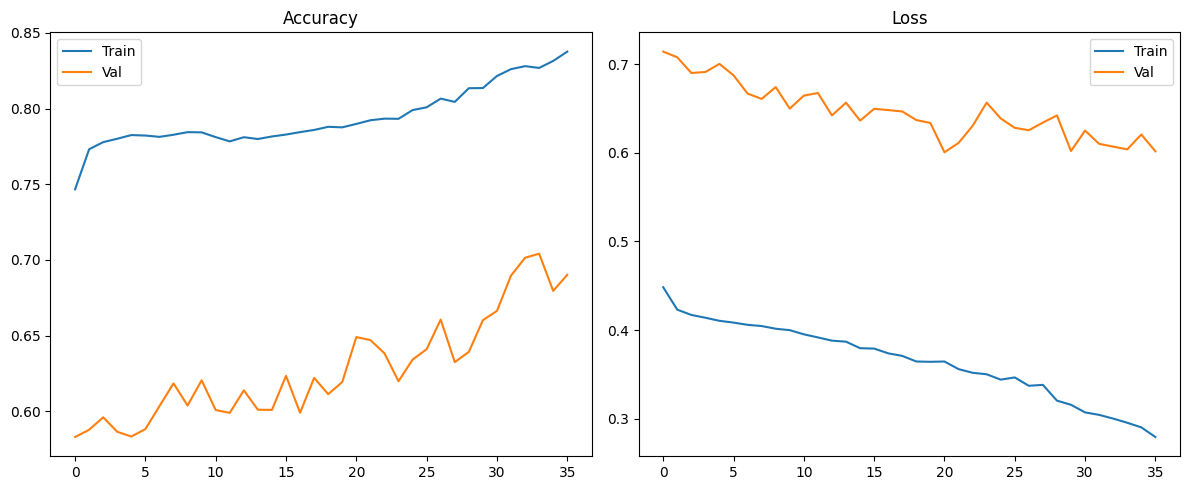


TRAINING SELESAI. MODEL SIAP DIGUNAKAN.
Model   : ./model_output_prediksi_1jam_sidangV1\best_model.keras
Scaler  : ./model_output_prediksi_1jam_sidangV1\scaler_X.joblib
Results : ./model_output_prediksi_1jam_sidangV1\test_predictions.csv


In [1]:
# ============================
# Model LSTM Prediksi 1 Jam Kedepan
# Time-Based Split
# ============================

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ===============================
# 0. Reproducibility
# ===============================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ===============================
# 1. Paths & Config
# ===============================
DATA_PATH = r'./sensor_curah_corrected_finalV2.csv'
OUT_DIR = r'./model_output_prediksi_1jam_sidangV1'
os.makedirs(OUT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(OUT_DIR, 'best_model.keras')
SCALER_PATH = os.path.join(OUT_DIR, 'scaler_X.joblib')
HISTORY_CSV = os.path.join(OUT_DIR, 'training_history.csv')
TEST_PRED_CSV = os.path.join(OUT_DIR, 'test_predictions.csv')
BEST_THR_TXT = os.path.join(OUT_DIR, 'best_threshold.txt')

# ===============================
# 2. Parameters
# ===============================
time_steps = 12        # 1 jam history (12 x 5 menit)
horizon_steps = 12     # 1 jam ke depan
test_size = 0.2
batch_size = 64
epochs = 500

# ===============================
# 3. Load & Prepare Data
# ===============================
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

# Datetime
if 'Datetime' not in df.columns:
    df['Datetime'] = pd.to_datetime(
        df['Tanggal'].astype(str) + ' ' + df['Jam'].astype(str),
        dayfirst=True, errors='coerce'
    )

df = df.sort_values('Datetime').reset_index(drop=True)

# ===============================
# 4. Target & FEATURES
# ===============================
TARGET_COL = 'Curah_Hujan_corrected'
FEATURES = [
    'Curah_Hujan_corrected',
    'Curah_Hujan_original',
    'Suhu',
    'Kelembaban',
    'Kecepatan_Angin'
]

missing = [f for f in FEATURES if f not in df.columns]
if missing:
    raise ValueError(f"Fitur tidak ditemukan: {missing}")

# Convert numeric
for c in FEATURES + [TARGET_COL]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df.interpolate(method='linear', inplace=True, limit_direction='both')
df.dropna(subset=FEATURES + [TARGET_COL], inplace=True)
df.reset_index(drop=True, inplace=True)

# Binary label
df['Hujan'] = (df[TARGET_COL] > 0).astype(int)

print("Class distribution:", df['Hujan'].value_counts().to_dict())

# ===============================
# 5. Prepare raw X and y (NO SCALING)
# ===============================
X_all = df[FEATURES].values
y_all = df['Hujan'].values

# ===============================
# 6. Create Sequences (Single-step Horizon)
# ===============================
def create_sequences(X, y, time_steps, horizon_steps):
    Xs, ys, idxs = [], [], []
    max_i = len(X) - time_steps - horizon_steps + 1

    for i in range(max_i):
        Xs.append(X[i:i+time_steps])
        label_idx = i + time_steps + horizon_steps - 1
        ys.append(y[label_idx])
        idxs.append(label_idx)

    return np.array(Xs), np.array(ys), np.array(idxs)

X_seq, y_seq, idx_seq = create_sequences(
    X_all, y_all,
    time_steps=time_steps,
    horizon_steps=horizon_steps
)

print("Sequence shape:", X_seq.shape)

# ===============================
# 7. Time-based Train/Test Split
# ===============================
split_idx = int(len(X_seq) * (1 - test_size))

X_train = X_seq[:split_idx]
X_test  = X_seq[split_idx:]

y_train = y_seq[:split_idx]
y_test  = y_seq[split_idx:]

idx_train = idx_seq[:split_idx]
idx_test  = idx_seq[split_idx:]

print("Train samples:", len(y_train))
print("Test samples :", len(y_test))

# ===============================
# 8. Scaling (FIT ONLY ON TRAIN)
# ===============================
scaler_X = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d  = X_test.reshape(-1, X_test.shape[2])

scaler_X.fit(X_train_2d)

X_train = scaler_X.transform(X_train_2d).reshape(X_train.shape)
X_test  = scaler_X.transform(X_test_2d).reshape(X_test.shape)

joblib.dump(scaler_X, SCALER_PATH)

# ===============================
# 9. Class Weights
# ===============================
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}

# ===============================
# 10. Build LSTM Model
# ===============================
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(time_steps, X_train.shape[2])),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ===============================
# 11. Callbacks
# ===============================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=7, factor=0.5, min_lr=1e-6),
    ModelCheckpoint(BEST_MODEL_PATH, monitor='val_loss', save_best_only=True)
]

# ===============================
# 12. Train Model
# ===============================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

pd.DataFrame(history.history).to_csv(HISTORY_CSV, index=False)

# ===============================
# 13. Evaluation & Best Threshold
# ===============================
y_pred_prob = model.predict(X_test).flatten()

thr_grid = np.arange(0.1, 0.9, 0.01)
best_thr, best_f1 = 0.5, -1

for thr in thr_grid:
    y_pred = (y_pred_prob >= thr).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

y_pred_best = (y_pred_prob >= best_thr).astype(int)

print("\n=== BEST THRESHOLD BY F1 ===")
print(f"Threshold : {best_thr:.2f}")
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_best, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred_best, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_best))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_prob))

with open(BEST_THR_TXT, "w") as f:
    f.write(f"{best_thr:.4f}")

# ===============================
# 14. Save Prediction Results
# ===============================
df_out = df.iloc[idx_test].copy().reset_index(drop=True)
df_out['y_true'] = y_test
df_out['pred_prob'] = y_pred_prob
df_out['pred_best'] = y_pred_best

df_out.to_csv(TEST_PRED_CSV, index=False)

# ===============================
# 15. Plot Training Curves
# ===============================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.show()

print("\nTRAINING SELESAI. MODEL SIAP DIGUNAKAN.")
print("Model   :", BEST_MODEL_PATH)
print("Scaler  :", SCALER_PATH)
print("Results :", TEST_PRED_CSV)


Loading data: .\sensor_curah_corrected_finalV2.csv
Columns: ['Tanggal', 'Jam', 'Curah_Hujan', 'MQ-7', 'MQ-135', 'PM-2.5', 'PM-10', 'Arah Angin', 'Kecepatan_Angin', 'Kelembaban', 'Suhu', 'SO2', 'O3', 'O3_2', 'Datetime', 'Curah_Hujan_original', 'date', 'rh_prev', 'delta_rh', 'rh_roll', 'temp_roll', 'temp_drop', 'pred_sensor', 'Curah_Hujan_corrected', 'is_synthetic']


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5964\1036839845.py:67: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(


Created Datetime from 'Tanggal' + 'Jam'.
Target distribution: {0: 44792, 1: 3217}
FEATURES used: ['Curah_Hujan_corrected', 'Curah_Hujan_original', 'Suhu', 'Kelembaban', 'Kecepatan_Angin']
Rows after cleaning: 48009
Class distribution (overall): {0: 44792, 1: 3217}
Saved scaler to: .\model_output_prediksi_1jam_sidangV2\scaler_X.joblib
Sequences created: (47986, 12, 5) (47986,)
Train shape: (38388, 12, 5) Test shape: (9598, 12, 5)
Train class counts: [35814  2574] Test class counts: [8955  643]
Class weights: {0: 0.5359356676160161, 1: 7.456876456876457}


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5964\1036839845.py:125: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(method='linear', inplace=True, limit_direction='both')
C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 12, 128)             │          68,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 12, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 12, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 12, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 130,977 (511.63 KB)

 Trainable params: 130,977 (511.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7106 - loss: 0.5027
Epoch 1: val_loss improved from inf to 0.47022, saving model to .\model_output_prediksi_1jam_sidangV2\best_model.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7107 - loss: 0.5026 - val_accuracy: 0.7170 - val_loss: 0.4702 - learning_rate: 0.0010
Epoch 2/500
599/600 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7593 - loss: 0.4527
Epoch 2: val_loss improved from 0.47022 to 0.45463, saving model to .\model_output_prediksi_1jam_sidangV2\best_model.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7593 - loss: 0.4527 - val_accuracy: 0.7460 - val_loss: 0.4546 - learning_rate: 0.0010
Epoch 3/500
597/600 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7667 - loss: 0.4419
Epoch 3: val_loss improved from 0.45463 to 0.45229, saving model to .\model_output_prediksi_1jam_sidangV2\best_model.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7668 - loss: 0.4419 - val_ac

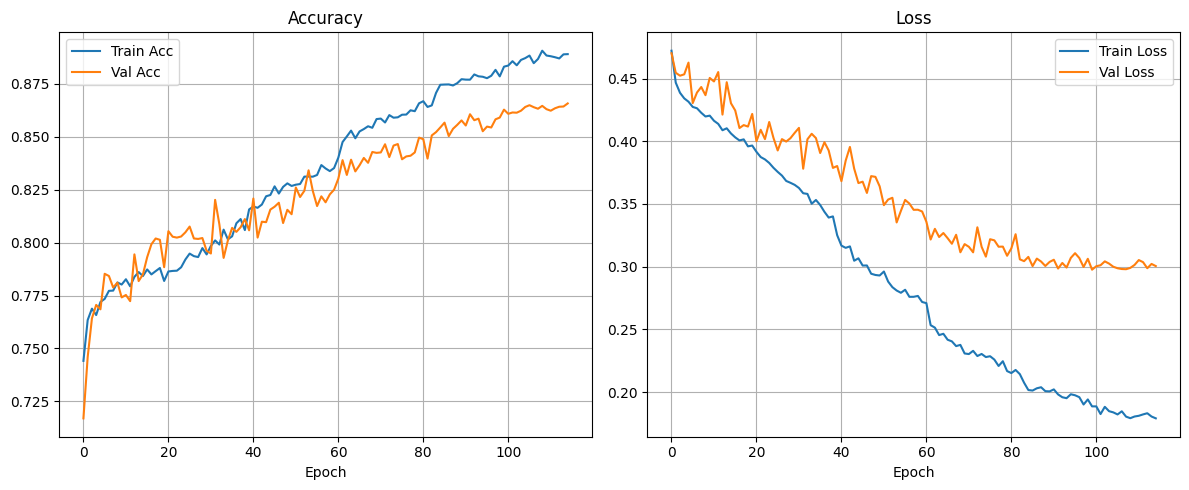


Top 20 predicted rainy rows (@thr=0.65):
           Datetime  Curah_Hujan_corrected  Curah_Hujan_corrected  Curah_Hujan_original  Suhu  pred_prob  pred_0.65
2024-11-13 23:20:00               0.000000               0.000000                     0  22.0   0.797836          1
2024-11-18 06:55:00               0.000000               0.000000                     0  23.0   0.815587          1
2024-11-24 19:54:00               0.539130               0.539130                     0  21.0   0.919163          1
2024-11-16 17:09:00               0.200000               0.200000                     0  23.0   0.942440          1
2025-01-11 04:30:00               0.000000               0.000000                     0  20.0   0.755828          1
2025-03-03 17:02:00               0.000000               0.000000                     0  23.0   0.844882          1
2024-11-18 14:51:00               0.000000               0.000000                     0  23.0   0.979109          1
2024-11-08 02:44:00           

In [5]:
# ============================
# Run your LSTM model on edited sensor data
# Prediksi: 1 jam ke depan (12 step)
# ============================
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow as tf

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Paths (ubah sesuai file edited-mu)
# -----------------------------
DATA_PATH = r'.\sensor_curah_corrected_finalV2.csv'   # <-- ganti jika perlu
OUT_DIR = r'.\model_output_prediksi_1jam_sidangV2'
os.makedirs(OUT_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(OUT_DIR, 'best_model.keras')   # must end with .keras
SCALER_PATH = os.path.join(OUT_DIR, 'scaler_X.joblib')
HISTORY_CSV = os.path.join(OUT_DIR, 'training_history.csv')
TEST_PRED_CSV = os.path.join(OUT_DIR, 'test_predictions.csv')

# ===============================
# User-configurable params
# ===============================
# time_steps: panjang history (12 step = 1 jam ke belakang untuk data 5 menit)
time_steps = 12        # 1 jam history
horizon_steps = 12     # 1 jam ke depan (12 x 5 menit)
test_size = 0.2
batch_size = 64
epochs = 500
use_time_index = True
thresholds_to_check = [0.5, 0.3, 0.65]

# ===============================
# 1. Baca CSV
# ===============================
print("Loading data:", DATA_PATH)
df = pd.read_csv(DATA_PATH)
print("Columns:", df.columns.tolist())

# Rapikan nama kolom
df.columns = [c.strip() if isinstance(c, str) else c for c in df.columns]

# ===============================
# 1b. Build Datetime (if needed)
# ===============================
if ('Tanggal' in df.columns) and ('Jam' in df.columns) and use_time_index:
    try:
        df['Datetime'] = pd.to_datetime(
            df['Tanggal'].astype(str) + ' ' + df['Jam'].astype(str),
            dayfirst=True,
            errors='coerce'
        )
        print("Created Datetime from 'Tanggal' + 'Jam'.")
    except Exception as e:
        print("Datetime parsing warning:", e)
else:
    for c in df.columns:
        if isinstance(c, str) and ('datetime' in c.lower() or 'timestamp' in c.lower()):
            df['Datetime'] = pd.to_datetime(df[c], errors='coerce')
            print("Using existing datetime column:", c)
            break

# ===============================
# 2. Tentukan TARGET (HUJAN / TIDAK HUJAN)
# ===============================

TARGET_COL = 'Curah_Hujan_corrected'

if TARGET_COL not in df.columns:
    raise ValueError(f"Target '{TARGET_COL}' tidak ditemukan di dataset")

# Konversi target ke numeric
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors='coerce')

# Label biner (klasifikasi)
df['Hujan'] = (df[TARGET_COL] > 0).astype(int)

print("Target distribution:", df['Hujan'].value_counts().to_dict())

# ===============================
# 3. Tentukan FEATURE (INPUT MODEL)
# ===============================

FEATURES = [
    'Curah_Hujan_corrected',   # historis hujan (BMKG distributed)
    'Curah_Hujan_original',    # sensor hujan asli
    'Suhu',
    'Kelembaban',
    'Kecepatan_Angin'
]

# Pastikan semua feature ada
missing_FEATURES = [f for f in FEATURES if f not in df.columns]
if missing_FEATURES:
    raise ValueError(f"Feature tidak ditemukan di dataset: {missing_FEATURES}")

print("FEATURES used:", FEATURES)

# ===============================
# 4. Bersihkan & konversi numeric
# ===============================
for c in FEATURES + [TARGET_COL]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.sort_values('Datetime') if 'Datetime' in df.columns else df
df.interpolate(method='linear', inplace=True, limit_direction='both')
df.dropna(subset=FEATURES + [TARGET_COL], inplace=True)
df = df.reset_index(drop=True)

print("Rows after cleaning:", len(df))

# ===============================
# 5. Label biner (Hujan / Tidak Hujan)
# ===============================
df['Hujan'] = (df[TARGET_COL].astype(float) > 0).astype(int)
print("Class distribution (overall):", df['Hujan'].value_counts().to_dict())

# ===============================
# 6. Scaling fitur
# ===============================
scaler_X = StandardScaler()
X_all = scaler_X.fit_transform(df[FEATURES].astype(float).values)
joblib.dump(scaler_X, SCALER_PATH)
print("Saved scaler to:", SCALER_PATH)

y_all = df['Hujan'].values

# ===============================
# 7. Buat sequences: history 1 jam → label 1 jam ke depan
# ===============================
def create_sequences(X, y, time_steps=12, horizon_steps=12):
    """
    X : array (N, n_FEATURES)
    y : array (N,)
    time_steps    : panjang history (misal 12 step = 1 jam)
    horizon_steps : jarak ke depan (misal 12 step = 1 jam)
    Output:
      Xs : (n_seq, time_steps, n_FEATURES)
      ys : (n_seq,)  -> label di waktu t + horizon
      idxs : index baris df untuk waktu t + horizon (waktu yang diprediksi)
    """
    Xs, ys, idxs = [], [], []
    max_i = len(X) - time_steps - horizon_steps + 1
    for i in range(max_i):
        Xs.append(X[i : i + time_steps])  # history
        label_idx = i + time_steps + horizon_steps - 1
        ys.append(y[label_idx])           # kondisi 1 jam ke depan
        idxs.append(label_idx)            # index waktu 1 jam ke depan
    return np.array(Xs), np.array(ys), np.array(idxs)

X_seq, y_seq, idx_seq = create_sequences(
    X_all, y_all,
    time_steps=time_steps,
    horizon_steps=horizon_steps
)
print("Sequences created:", X_seq.shape, y_seq.shape)

# ===============================
# 8. Split train/test (stratify by label)
# ===============================
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_seq, y_seq, idx_seq,
    test_size=test_size,
    stratify=y_seq,
    random_state=SEED
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class counts:", np.bincount(y_train), "Test class counts:", np.bincount(y_test))

# ===============================
# 9. Class weights
# ===============================
classes = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}
print("Class weights:", class_weight_dict)

# ===============================
# 10. Build model (arsitektur tetap)
# ===============================
n_FEATURES = X_train.shape[2]
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(time_steps, n_FEATURES)),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ===============================
# 11. Callbacks
# ===============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)
checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
callbacks = [early_stop, reduce_lr, checkpoint]

# ===============================
# 12. Train
# ===============================
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# Save history
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(HISTORY_CSV, index=False)
print("Saved training history to:", HISTORY_CSV)

# ===============================
# 13. Predict on test set
# ===============================
y_pred_prob = model.predict(X_test).flatten()
results = {}
for thr in thresholds_to_check:
    y_pred = (y_pred_prob >= thr).astype(int)
    results[thr] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "confusion": confusion_matrix(y_test, y_pred)
    }

for thr, r in results.items():
    print(f"\n=== Threshold {thr} ===")
    print(f"Accuracy: {r['accuracy']:.4f}  Precision: {r['precision']:.4f}  Recall: {r['recall']:.4f}  F1: {r['f1']:.4f}")
    print("Confusion matrix:\n", r['confusion'])

try:
    roc = roc_auc_score(y_test, y_pred_prob)
    print("\nTest ROC AUC:", roc)
except Exception as e:
    print("ROC AUC error:", e)

# ===============================
# 14. Save test predictions mapped back to original df rows
#      idx_test sekarang menunjuk ke waktu T+1 jam (horizon)
# ===============================
df_seq_index = idx_test   # index baris df untuk waktu 1 jam ke depan
df_labels = df.reset_index(drop=True).iloc[df_seq_index].copy().reset_index(drop=True)

df_labels['y_true'] = y_test
df_labels['pred_prob'] = y_pred_prob
for thr in thresholds_to_check:
    df_labels[f'pred_{thr}'] = (df_labels['pred_prob'] >= thr).astype(int)

df_labels.to_csv(TEST_PRED_CSV, index=False)
print("Saved test predictions to:", TEST_PRED_CSV)

# ===============================
# 15. Visualize training curves
# ===============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history.get('accuracy', []), label='Train Acc')
plt.plot(history.history.get('val_accuracy', []), label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history.get('loss', []), label='Train Loss')
plt.plot(history.history.get('val_loss', []), label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ===============================
# 16. Print top predicted rainy rows (threshold recommended 0.65)
# ===============================
thr = 0.65
if f'pred_{thr}' in df_labels.columns:
    df_rain_pred = df_labels[df_labels[f'pred_{thr}'] == 1]
    print(f"\nTop {min(20,len(df_rain_pred))} predicted rainy rows (@thr={thr}):")
    display_cols = []
    if 'Datetime' in df_rain_pred.columns:
        display_cols.append('Datetime')
    display_cols += [TARGET_COL] + FEATURES[:3] + ['pred_prob', f'pred_{thr}']
    display_cols = [c for c in display_cols if c in df_rain_pred.columns]
    print(df_rain_pred[display_cols].head(20).to_string(index=False))
else:
    print("Prediction column for recommended threshold not found in saved results.")

print("\nFinished. Best model saved to:", BEST_MODEL_PATH)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5964\2949110402.py:91: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(method='linear', inplace=True, limit_direction='both')


Distribusi kelas: {0: 44792, 1: 3217}
Sequence shape: (47986, 12, 5)
Train samples: 38388
Test samples : 9598
Class weight: {0: 0.5337894209911563, 1: 7.898765432098766}


C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 12, 128)             │          68,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 12, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 12, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 12, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_8 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 130,977 (511.63 KB)

 Trainable params: 130,977 (511.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.7084 - loss: 0.4786 - val_accuracy: 0.6041 - val_loss: 0.6854 - learning_rate: 0.0010
Epoch 2/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7717 - loss: 0.4240 - val_accuracy: 0.5884 - val_loss: 0.7081 - learning_rate: 0.0010
Epoch 3/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7766 - loss: 0.4172 - val_accuracy: 0.6002 - val_loss: 0.6835 - learning_rate: 0.0010
Epoch 4/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7826 - loss: 0.4127 - val_accuracy: 0.5977 - val_loss: 0.6783 - learning_rate: 0.0010
Epoch 5/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7824 - loss: 0.4092 - val_accuracy: 0.6097 - val_loss: 0.6667 - learning_rate: 0.0010
Epoch 6/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7814 - loss: 0.4060 - val_accuracy: 0.6121 - val_loss: 0.6556 - learning_rate: 0.0010
Epoch 7/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7

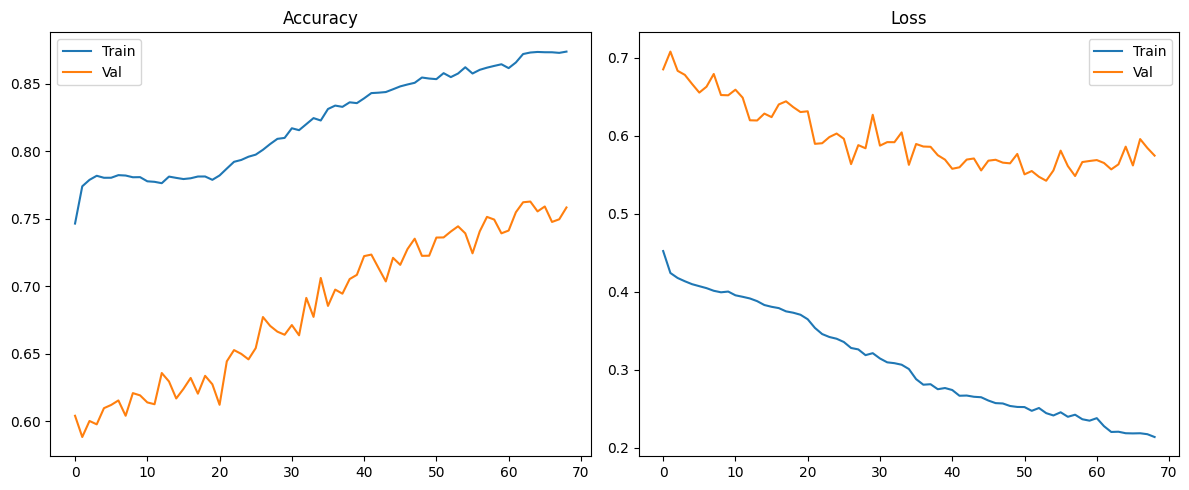


TRAINING SELESAI — MODEL TIME-BASED SIAP DIGUNAKAN
Model  : ./model_output_prediksi_1jam_sidangV3\best_model.keras
Scaler : ./model_output_prediksi_1jam_sidangV3\scaler_X.joblib


In [6]:
# ============================
# LSTM Prediksi Hujan 1 Jam ke Depan
# TIME-BASED SPLIT (VALID TIME SERIES)
# ============================

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ===============================
# 0. Reproducibility
# ===============================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ===============================
# 1. Paths & Config
# ===============================
DATA_PATH = r'./sensor_curah_corrected_finalV2.csv'
OUT_DIR = r'./model_output_prediksi_1jam_sidangV3'
os.makedirs(OUT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(OUT_DIR, 'best_model.keras')
SCALER_PATH = os.path.join(OUT_DIR, 'scaler_X.joblib')
HISTORY_CSV = os.path.join(OUT_DIR, 'training_history.csv')
TEST_PRED_CSV = os.path.join(OUT_DIR, 'test_predictions.csv')
BEST_THR_TXT = os.path.join(OUT_DIR, 'best_threshold.txt')

# ===============================
# 2. Parameters
# ===============================
time_steps = 12        # 1 jam history (12 x 5 menit)
horizon_steps = 12     # 1 jam ke depan
test_ratio = 0.2
batch_size = 64
epochs = 500

# ===============================
# 3. Load & Prepare Data
# ===============================
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

# Build Datetime
if 'Datetime' not in df.columns:
    df['Datetime'] = pd.to_datetime(
        df['Tanggal'].astype(str) + ' ' + df['Jam'].astype(str),
        dayfirst=True,
        errors='coerce'
    )

df = df.sort_values('Datetime').reset_index(drop=True)

# ===============================
# 4. Target & Features (FOCUS)
# ===============================
TARGET_COL = 'Curah_Hujan_corrected'

FEATURES = [
    'Curah_Hujan_corrected',
    'Curah_Hujan_original',
    'Suhu',
    'Kelembaban',
    'Kecepatan_Angin'
]

# Validasi kolom
missing = [c for c in FEATURES + [TARGET_COL] if c not in df.columns]
if missing:
    raise ValueError(f"Kolom tidak ditemukan: {missing}")

# Konversi numeric
for c in FEATURES + [TARGET_COL]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df.interpolate(method='linear', inplace=True, limit_direction='both')
df.dropna(subset=FEATURES + [TARGET_COL], inplace=True)
df.reset_index(drop=True, inplace=True)

# Binary label
df['Hujan'] = (df[TARGET_COL] > 0).astype(int)
print("Distribusi kelas:", df['Hujan'].value_counts().to_dict())

# ===============================
# 5. Raw X & y (BELUM DISCALING)
# ===============================
X_raw = df[FEATURES].values
y_raw = df['Hujan'].values

# ===============================
# 6. Create Sequences
# ===============================
def create_sequences(X, y, time_steps, horizon_steps):
    Xs, ys, idxs = [], [], []
    max_i = len(X) - time_steps - horizon_steps + 1

    for i in range(max_i):
        Xs.append(X[i:i+time_steps])
        label_idx = i + time_steps + horizon_steps - 1
        ys.append(y[label_idx])
        idxs.append(label_idx)

    return np.array(Xs), np.array(ys), np.array(idxs)

X_seq, y_seq, idx_seq = create_sequences(
    X_raw, y_raw,
    time_steps, horizon_steps
)

print("Sequence shape:", X_seq.shape)

# ===============================
# 7. TIME-BASED SPLIT
# ===============================
split_idx = int(len(X_seq) * (1 - test_ratio))

X_train = X_seq[:split_idx]
X_test  = X_seq[split_idx:]

y_train = y_seq[:split_idx]
y_test  = y_seq[split_idx:]

idx_test = idx_seq[split_idx:]

print("Train samples:", len(y_train))
print("Test samples :", len(y_test))

# ===============================
# 8. Scaling (FIT ONLY ON TRAIN)
# ===============================
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d  = X_test.reshape(-1, X_test.shape[2])

scaler.fit(X_train_2d)

X_train = scaler.transform(X_train_2d).reshape(X_train.shape)
X_test  = scaler.transform(X_test_2d).reshape(X_test.shape)

joblib.dump(scaler, SCALER_PATH)

# ===============================
# 9. Class Weights
# ===============================
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
print("Class weight:", class_weight)

# ===============================
# 10. Build LSTM Model
# ===============================
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(time_steps, X_train.shape[2])),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ===============================
# 11. Callbacks
# ===============================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=7, factor=0.5, min_lr=1e-6),
    ModelCheckpoint(BEST_MODEL_PATH, monitor='val_loss', save_best_only=True)
]

# ===============================
# 12. Train Model
# ===============================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

pd.DataFrame(history.history).to_csv(HISTORY_CSV, index=False)

# ===============================
# 13. Evaluation + Best Threshold
# ===============================
y_prob = model.predict(X_test).flatten()

thr_grid = np.arange(0.1, 0.9, 0.01)
best_thr, best_f1 = 0.5, -1

for thr in thr_grid:
    y_pred = (y_prob >= thr).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

y_best = (y_prob >= best_thr).astype(int)

print("\n=== BEST THRESHOLD (F1) ===")
print("Threshold :", best_thr)
print("Accuracy :", accuracy_score(y_test, y_best))
print("Precision:", precision_score(y_test, y_best, zero_division=0))
print("Recall   :", recall_score(y_test, y_best, zero_division=0))
print("F1-score :", f1_score(y_test, y_best, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))
print("Confusion matrix:\n", confusion_matrix(y_test, y_best))

with open(BEST_THR_TXT, "w") as f:
    f.write(str(best_thr))

# ===============================
# 14. Save Test Predictions
# ===============================
df_out = df.iloc[idx_test].copy().reset_index(drop=True)
df_out['y_true'] = y_test
df_out['pred_prob'] = y_prob
df_out['pred_best'] = y_best

df_out.to_csv(TEST_PRED_CSV, index=False)

# ===============================
# 15. Plot Curves
# ===============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("\nTRAINING SELESAI — MODEL TIME-BASED SIAP DIGUNAKAN")
print("Model  :", BEST_MODEL_PATH)
print("Scaler :", SCALER_PATH)


In [4]:
# Pastikan model & X_test sudah ada
y_prob = model.predict(X_test).flatten()

print("y_prob berhasil dibuat, shape:", y_prob.shape)


300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
y_prob berhasil dibuat, shape: (9598,)


In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import os

thr_grid = np.arange(0.1, 0.9, 0.01)

thr_list, prec_list, rec_list, f1_list = [], [], [], []

for thr in thr_grid:
    y_pred_thr = (y_prob >= thr).astype(int)

    thr_list.append(thr)
    prec_list.append(precision_score(y_test, y_pred_thr, zero_division=0))
    rec_list.append(recall_score(y_test, y_pred_thr, zero_division=0))
    f1_list.append(f1_score(y_test, y_pred_thr, zero_division=0))

df_multithr = pd.DataFrame({
    'Threshold': thr_list,
    'Precision': prec_list,
    'Recall': rec_list,
    'F1_score': f1_list
})

MULTI_THR_CSV = os.path.join(OUT_DIR, 'multithreshold_metrics.csv')
df_multithr.to_csv(MULTI_THR_CSV, index=False)

df_multithr.head()


,Threshold,Precision,Recall,F1_score
0,0.10,0.126606,0.864041,0.220851
1,0.11,0.128127,0.852605,0.222776
2,0.12,0.130053,0.846252,0.225457
3,0.13,0.131631,0.838628,0.227547
4,0.14,0.133878,0.833545,0.230702


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14520\4143810856.py:91: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(method='linear', inplace=True, limit_direction='both')


Distribusi kelas: {0: 44792, 1: 3217}
Sequence shape: (47974, 24, 5)
Train samples: 38379
Test samples : 9595
Class weight: {0: 0.5337978803304682, 1: 7.896913580246913}


C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 24, 128)             │          68,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 24, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 130,977 (511.63 KB)

 Trainable params: 130,977 (511.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.7182 - loss: 0.4913 - val_accuracy: 0.6655 - val_loss: 0.6408 - learning_rate: 0.0010
Epoch 2/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.7782 - loss: 0.4210 - val_accuracy: 0.6629 - val_loss: 0.6246 - learning_rate: 0.0010
Epoch 3/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.7758 - loss: 0.4129 - val_accuracy: 0.6593 - val_loss: 0.6188 - learning_rate: 0.0010
Epoch 4/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.7816 - loss: 0.4108 - val_accuracy: 0.6768 - val_loss: 0.6048 - learning_rate: 0.0010
Epoch 5/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.7811 - loss: 0.4055 - val_accuracy: 0.6537 - val_loss: 0.6207 - learning_rate: 0.0010
Epoch 6/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.7741 - loss: 0.4064 - val_accuracy: 0.6423 - val_loss: 0.6349 - learning_rate: 0.0010
Epoch 7/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.7

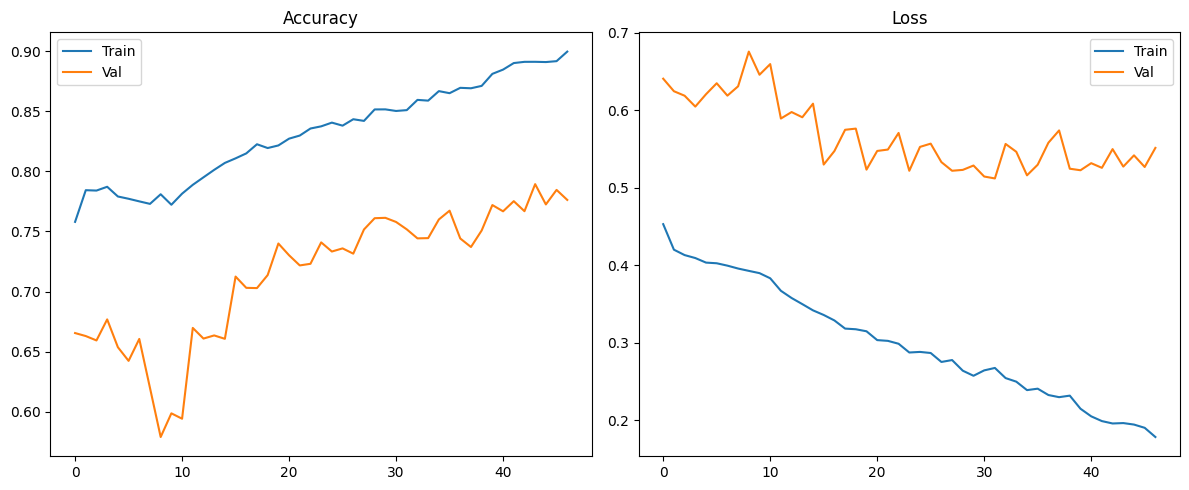


TRAINING SELESAI — MODEL TIME-BASED SIAP DIGUNAKAN
Model  : ./model_output_prediksi_1jam_sidangV4\best_model.keras
Scaler : ./model_output_prediksi_1jam_sidangV4\scaler_X.joblib


In [2]:
# ============================
# LSTM Prediksi Hujan 1 Jam ke Depan
# TIME-BASED SPLIT (VALID TIME SERIES)
# ============================

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ===============================
# 0. Reproducibility
# ===============================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ===============================
# 1. Paths & Config
# ===============================
DATA_PATH = r'./sensor_curah_corrected_finalV2.csv'
OUT_DIR = r'./model_output_prediksi_1jam_sidangV4'
os.makedirs(OUT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(OUT_DIR, 'best_model.keras')
SCALER_PATH = os.path.join(OUT_DIR, 'scaler_X.joblib')
HISTORY_CSV = os.path.join(OUT_DIR, 'training_history.csv')
TEST_PRED_CSV = os.path.join(OUT_DIR, 'test_predictions.csv')
BEST_THR_TXT = os.path.join(OUT_DIR, 'best_threshold.txt')

# ===============================
# 2. Parameters
# ===============================
time_steps = 24        # 1 jam history (12 x 5 menit)
horizon_steps = 12     # 1 jam ke depan
test_ratio = 0.2
batch_size = 64
epochs = 500

# ===============================
# 3. Load & Prepare Data
# ===============================
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

# Build Datetime
if 'Datetime' not in df.columns:
    df['Datetime'] = pd.to_datetime(
        df['Tanggal'].astype(str) + ' ' + df['Jam'].astype(str),
        dayfirst=True,
        errors='coerce'
    )

df = df.sort_values('Datetime').reset_index(drop=True)

# ===============================
# 4. Target & Features (FOCUS)
# ===============================
TARGET_COL = 'Curah_Hujan_corrected'

FEATURES = [
    'Curah_Hujan_corrected',
    'Curah_Hujan_original',
    'Suhu',
    'Kelembaban',
    'Kecepatan_Angin'
]

# Validasi kolom
missing = [c for c in FEATURES + [TARGET_COL] if c not in df.columns]
if missing:
    raise ValueError(f"Kolom tidak ditemukan: {missing}")

# Konversi numeric
for c in FEATURES + [TARGET_COL]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df.interpolate(method='linear', inplace=True, limit_direction='both')
df.dropna(subset=FEATURES + [TARGET_COL], inplace=True)
df.reset_index(drop=True, inplace=True)

# Binary label
df['Hujan'] = (df[TARGET_COL] > 0).astype(int)
print("Distribusi kelas:", df['Hujan'].value_counts().to_dict())

# ===============================
# 5. Raw X & y (BELUM DISCALING)
# ===============================
X_raw = df[FEATURES].values
y_raw = df['Hujan'].values

# ===============================
# 6. Create Sequences
# ===============================
def create_sequences(X, y, time_steps, horizon_steps):
    Xs, ys, idxs = [], [], []
    max_i = len(X) - time_steps - horizon_steps + 1

    for i in range(max_i):
        Xs.append(X[i:i+time_steps])
        label_idx = i + time_steps + horizon_steps - 1
        ys.append(y[label_idx])
        idxs.append(label_idx)

    return np.array(Xs), np.array(ys), np.array(idxs)

X_seq, y_seq, idx_seq = create_sequences(
    X_raw, y_raw,
    time_steps, horizon_steps
)

print("Sequence shape:", X_seq.shape)

# ===============================
# 7. TIME-BASED SPLIT
# ===============================
split_idx = int(len(X_seq) * (1 - test_ratio))

X_train = X_seq[:split_idx]
X_test  = X_seq[split_idx:]

y_train = y_seq[:split_idx]
y_test  = y_seq[split_idx:]

idx_test = idx_seq[split_idx:]

print("Train samples:", len(y_train))
print("Test samples :", len(y_test))

# ===============================
# 8. Scaling (FIT ONLY ON TRAIN)
# ===============================
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d  = X_test.reshape(-1, X_test.shape[2])

scaler.fit(X_train_2d)

X_train = scaler.transform(X_train_2d).reshape(X_train.shape)
X_test  = scaler.transform(X_test_2d).reshape(X_test.shape)

joblib.dump(scaler, SCALER_PATH)

# ===============================
# 9. Class Weights
# ===============================
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
print("Class weight:", class_weight)

# ===============================
# 10. Build LSTM Model
# ===============================
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(time_steps, X_train.shape[2])),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ===============================
# 11. Callbacks
# ===============================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=7, factor=0.5, min_lr=1e-6),
    ModelCheckpoint(BEST_MODEL_PATH, monitor='val_loss', save_best_only=True)
]

# ===============================
# 12. Train Model
# ===============================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

pd.DataFrame(history.history).to_csv(HISTORY_CSV, index=False)

# ===============================
# 13. Evaluation + Best Threshold
# ===============================
y_prob = model.predict(X_test).flatten()

thr_grid = np.arange(0.1, 0.9, 0.01)
best_thr, best_f1 = 0.5, -1

for thr in thr_grid:
    y_pred = (y_prob >= thr).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

y_best = (y_prob >= best_thr).astype(int)

print("\n=== BEST THRESHOLD (F1) ===")
print("Threshold :", best_thr)
print("Accuracy :", accuracy_score(y_test, y_best))
print("Precision:", precision_score(y_test, y_best, zero_division=0))
print("Recall   :", recall_score(y_test, y_best, zero_division=0))
print("F1-score :", f1_score(y_test, y_best, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))
print("Confusion matrix:\n", confusion_matrix(y_test, y_best))

with open(BEST_THR_TXT, "w") as f:
    f.write(str(best_thr))

# ===============================
# 14. Save Test Predictions
# ===============================
df_out = df.iloc[idx_test].copy().reset_index(drop=True)
df_out['y_true'] = y_test
df_out['pred_prob'] = y_prob
df_out['pred_best'] = y_best

df_out.to_csv(TEST_PRED_CSV, index=False)

# ===============================
# 15. Plot Curves
# ===============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("\nTRAINING SELESAI — MODEL TIME-BASED SIAP DIGUNAKAN")
print("Model  :", BEST_MODEL_PATH)
print("Scaler :", SCALER_PATH)


In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load hasil prediksi dari model sidangV3
df = pd.read_csv('./model_output_prediksi_1jam_sidangV3/test_predictions.csv')

y_true = df['y_true'].values
y_prob = df['pred_prob'].values

# Load best threshold
with open('./model_output_prediksi_1jam_sidangV3/best_threshold.txt') as f:
    best_thr = float(f.read().strip())

# Threshold yang ingin dievaluasi
thresholds = [0.30, 0.50, 0.65, best_thr]

results = []

for thr in thresholds:
    y_pred = (y_prob >= thr).astype(int)
    results.append({
        'Threshold': round(thr, 2),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1_score': f1_score(y_true, y_pred, zero_division=0)
    })

df_selected_thr = pd.DataFrame(results)

print("\n=== EVALUASI MULTI-THRESHOLD TERPILIH ===")
print(df_selected_thr)



=== EVALUASI MULTI-THRESHOLD TERPILIH ===
   Threshold  Accuracy  Precision    Recall  F1_score
0       0.30  0.671077   0.161622  0.719187  0.263931
1       0.50  0.744426   0.189411  0.645489  0.292880
2       0.65  0.801521   0.221336  0.564168  0.317938
3       0.73  0.844030   0.264276  0.505718  0.347143
